In [63]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

%matplotlib inline

In [64]:
data_path = "../data/raw/appendicitis_comprehensive_dataset.csv"

df = pd.read_csv(data_path)

display(df.head(10))
# display(df.info())
display(df.describe(include="all").T)
# display(df.shape)

,Patient_ID,Age,Gender,BMI,Is_Pregnant,Duration_of_Symptoms_Hours,Pain_Migration,Abdominal_Pain_Location,Nausea_Vomiting,Loss_of_Appetite,...,Rovsing_Sign,Psoas_Sign,WBC_Count_k_uL,Neutrophil_Percentage,CRP_Level_mg_L,Ultrasound_Findings,Pathological_Cause,Severity,Management,Final_Diagnosis
0,APX-0001,32,Female,23.4,No,17,Yes,RLQ,Yes,No,...,Yes,Yes,11.5,77.8,63.2,Non-visualized,Fecalith/Appendicolith,Uncomplicated,Laparoscopic Appendectomy,Appendicitis
1,APX-0002,5,Male,19.4,No,31,No,RLQ,No,No,...,Yes,No,12.6,74.7,89.1,Target Sign,Lymphoid Hyperplasia,Uncomplicated,Antibiotics (Conservative),Appendicitis
2,APX-0003,28,Female,27.5,No,49,Yes,RLQ,Yes,Yes,...,No,Yes,16.2,77.0,92.9,Periappendiceal Fluid,Lymphoid Hyperplasia,Uncomplicated,Laparoscopic Appendectomy,Appendicitis
3,APX-0004,20,Male,28.7,No,32,No,RLQ,Yes,Yes,...,Yes,Yes,19.1,88.3,12.7,Periappendiceal Fluid,Fecalith/Appendicolith,Uncomplicated,Laparoscopic Appendectomy,Appendicitis
4,APX-0005,12,Female,22.0,No,47,No,RLQ,No,No,...,Yes,No,12.2,65.0,8.8,Normal,NaN,NaN,Observation/Other,Other (Ectopic Pregnancy (if pregnant))
5,APX-0006,21,Female,20.4,No,43,Yes,RLQ,Yes,Yes,...,Yes,No,11.3,81.5,34.8,Appendicolith Seen,Lymphoid Hyperplasia,Uncomplicated,Laparoscopic Appendectomy,Appendicitis
6,APX-0007,57,Male,28.9,No,19,Yes,Generalized,No,Yes,...,No,No,11.2,78.8,28.0,Enlarged (>6mm),Unknown,Uncomplicated,Laparoscopic Appendectomy,Appendicitis
7,APX-0008,41,Female,28.7,No,28,Yes,Generalized,Yes,Yes,...,Yes,Yes,16.9,87.5,70.6,Periappendiceal Fluid,Unknown,Complicated (Perforated/Gangrenous),Open Appendectomy,Appendicitis
8,APX-0009,21,Female,26.3,No,8,Yes,Generalized,Yes,Yes,...,Yes,No,14.4,82.9,199.8,Target Sign,Unknown,Uncomplicated,Antibiotics (Conservative),Appendicitis
9,APX-0010,5,Female,20.6,No,29,No,RLQ,Yes,Yes,...,No,Yes,20.9,79.1,42.0,Enlarged (>6mm),Lymphoid Hyperplasia,Uncomplicated,Laparoscopic Appendectomy,Appendicitis


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,1500,1500,APX-0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1500.0,NaN,NaN,NaN,25.396667,13.894796,5.0,14.0,25.0,34.0,79.0
Gender,1500,2,Male,815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,1500.0,NaN,NaN,NaN,24.028933,3.860667,16.0,21.3,23.9,26.6,35.4
Is_Pregnant,1500,2,No,1485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration_of_Symptoms_Hours,1500.0,NaN,NaN,NaN,30.05,19.21594,2.0,16.0,26.0,39.0,96.0
Pain_Migration,1500,2,Yes,880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Abdominal_Pain_Location,1500,7,RLQ,1058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nausea_Vomiting,1500,2,Yes,1081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loss_of_Appetite,1500,2,Yes,1067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

display(missing_table)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

categorical_cols = df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    print("\nColumn:", col)
    print(df[col].value_counts(dropna=False).head(15))

,missing_count,missing_pct
Patient_ID,0,0.00
Age,0,0.00
Gender,0,0.00
BMI,0,0.00
Is_Pregnant,0,0.00
Duration_of_Symptoms_Hours,0,0.00
Pain_Migration,0,0.00
Abdominal_Pain_Location,0,0.00
Nausea_Vomiting,0,0.00
Loss_of_Appetite,0,0.00


Number of duplicate rows: 0

Column: Patient_ID
Patient_ID
APX-0001    1
APX-0002    1
APX-0003    1
APX-0004    1
APX-0005    1
APX-0006    1
APX-0007    1
APX-0008    1
APX-0009    1
APX-0010    1
APX-0011    1
APX-0012    1
APX-0013    1
APX-0014    1
APX-0015    1
Name: count, dtype: int64

Column: Gender
Gender
Male      815
Female    685
Name: count, dtype: int64

Column: Is_Pregnant
Is_Pregnant
No     1485
Yes      15
Name: count, dtype: int64

Column: Pain_Migration
Pain_Migration
Yes    880
No     620
Name: count, dtype: int64

Column: Abdominal_Pain_Location
Abdominal_Pain_Location
RLQ              1058
Periumbilical     192
Generalized       116
LLQ                51
Epigastric         42
Pelvic             35
RUQ                 6
Name: count, dtype: int64

Column: Nausea_Vomiting
Nausea_Vomiting
Yes    1081
No      419
Name: count, dtype: int64

Column: Loss_of_Appetite
Loss_of_Appetite
Yes    1067
No      433
Name: count, dtype: int64

Column: Rebound_Tenderness
Rebound_T

,count,percentage %
Final_Diagnosis,,
Appendicitis,1190,79.33
Other (Gastroenteritis),76,5.07
Other (Mesenteric Adenitis),67,4.47
Other (UTI),61,4.07
Other (Kidney Stones),38,2.53
Other (PID),26,1.73
Other (Ovarian Cyst Rupture),24,1.60
Other (Ectopic Pregnancy (if pregnant)),18,1.20


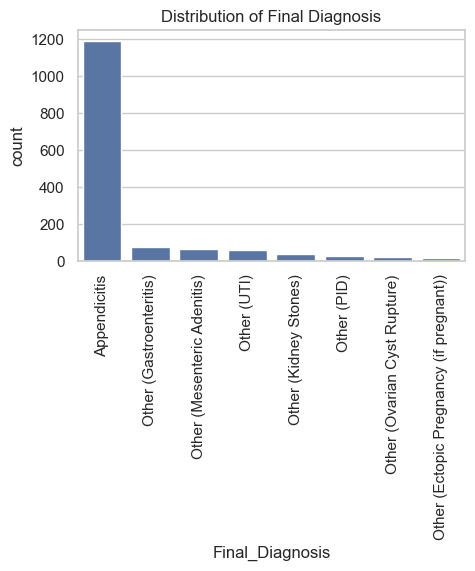

In [66]:
target_col = 'Final_Diagnosis'

target_counts = df[target_col].value_counts(dropna=False)
target_pct = (df[target_col].value_counts(dropna=False, normalize=True)* 100).round(2)

target_table = pd.DataFrame({
    'count': target_counts,
    'percentage %': target_pct
})
display(target_table)\
    
    
plt.figure(figsize=(5, 3))
sns.countplot(x=target_col, data=df, order=df[target_col].value_counts().index)
plt.title('Distribution of Final Diagnosis')
plt.xticks(rotation=90)
plt.show()

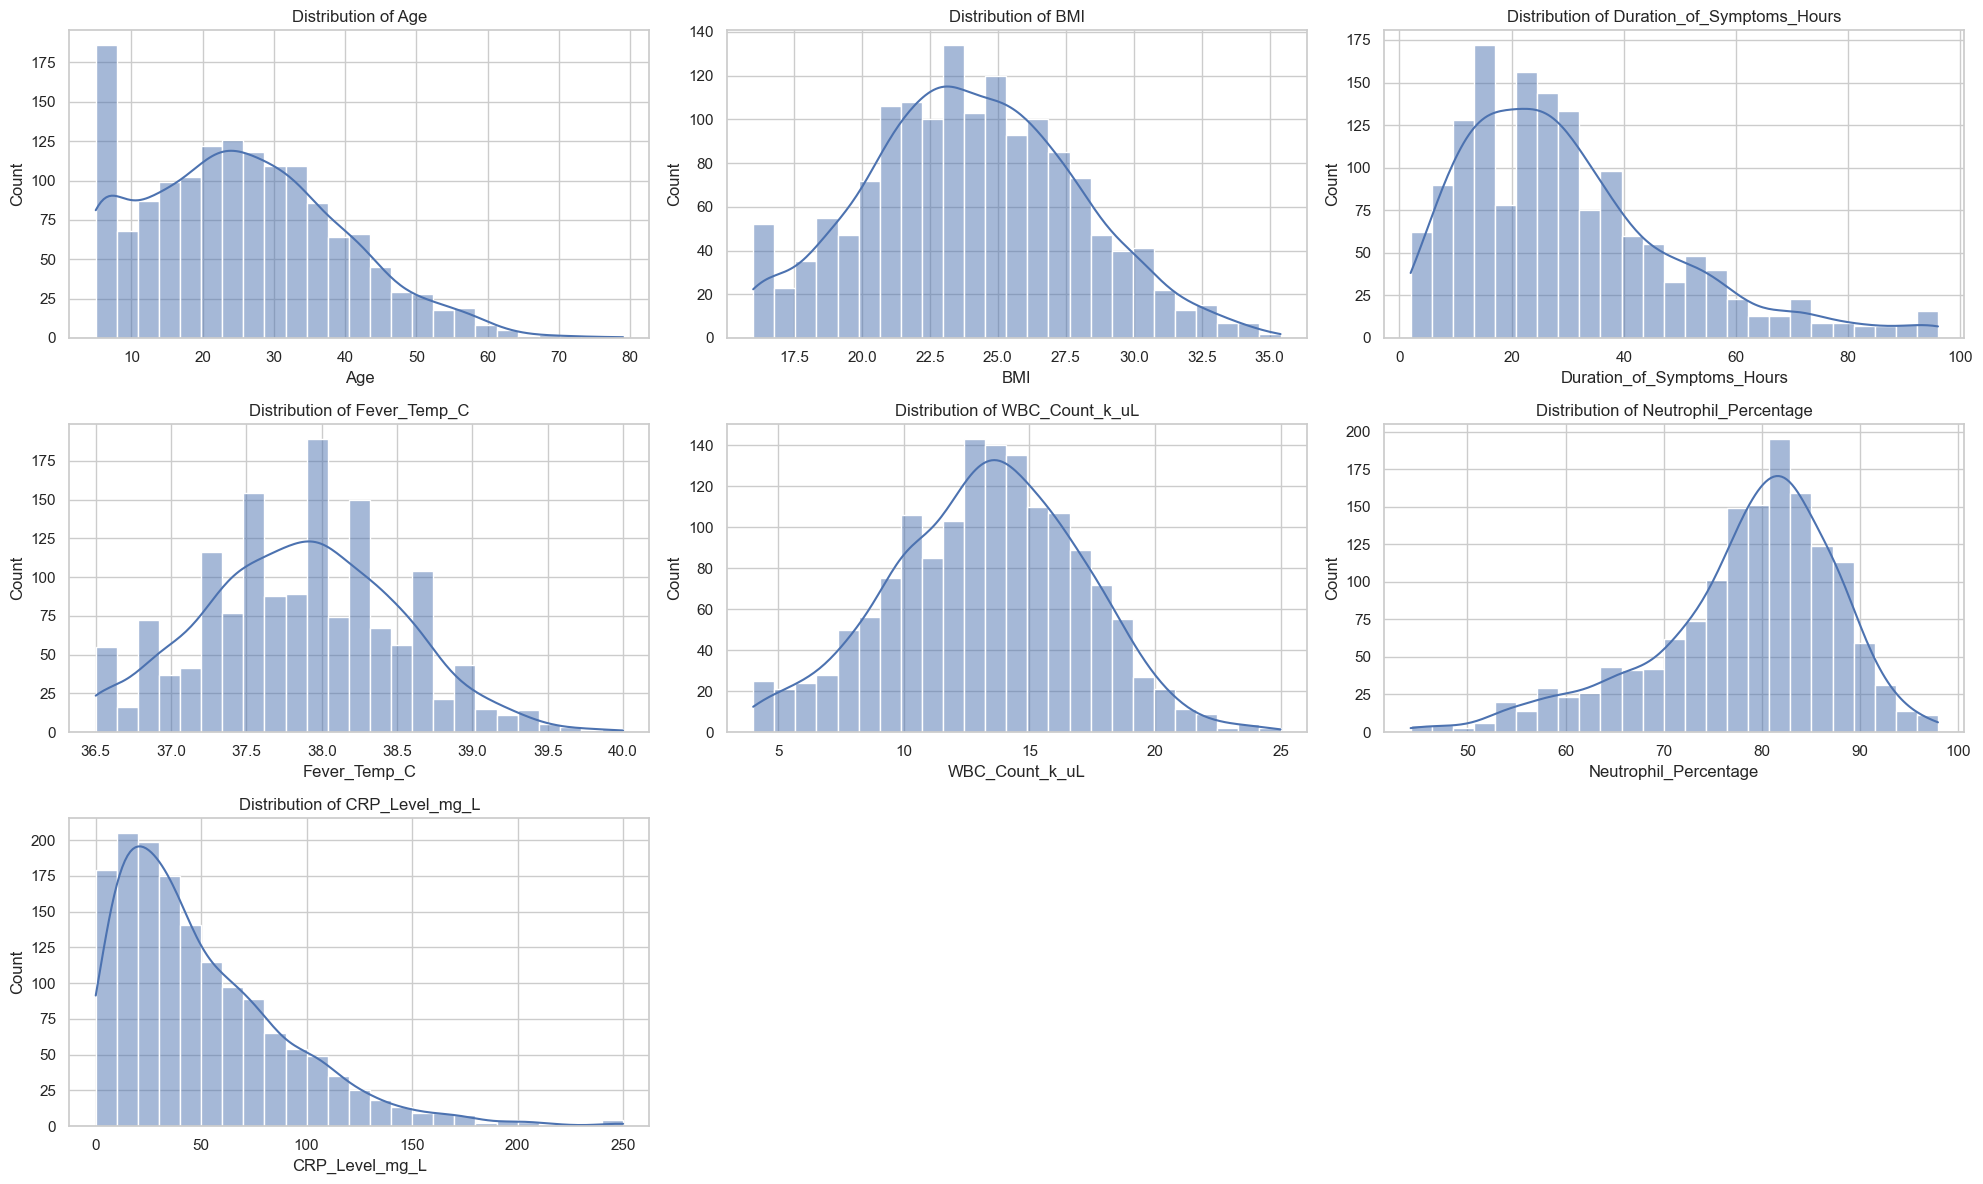

In [67]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


plt.figure(figsize=(20, 12))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=25)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()    

In [68]:

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum()

outlier_summary = pd.DataFrame({
    "column": numeric_cols,
    "outlier_count": [iqr_outlier_count(df[c].dropna()) for c in numeric_cols]
})
outlier_summary["outlier_pct"] = (outlier_summary["outlier_count"] / len(df) * 100).round(2)
display(outlier_summary.sort_values("outlier_pct", ascending=False))

,column,outlier_count,outlier_pct
2,Duration_of_Symptoms_Hours,56,3.73
5,Neutrophil_Percentage,53,3.53
6,CRP_Level_mg_L,41,2.73
3,Fever_Temp_C,6,0.40
0,Age,6,0.40
1,BMI,3,0.20
4,WBC_Count_k_uL,2,0.13


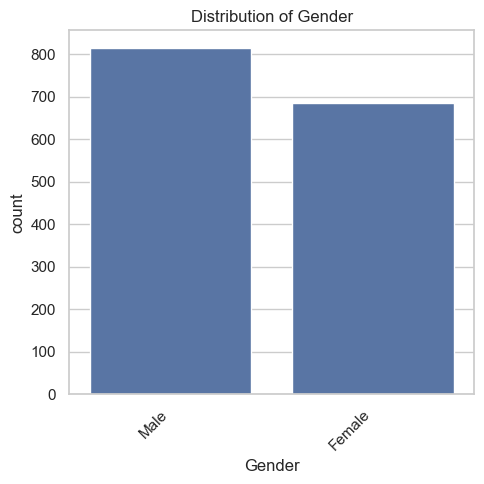

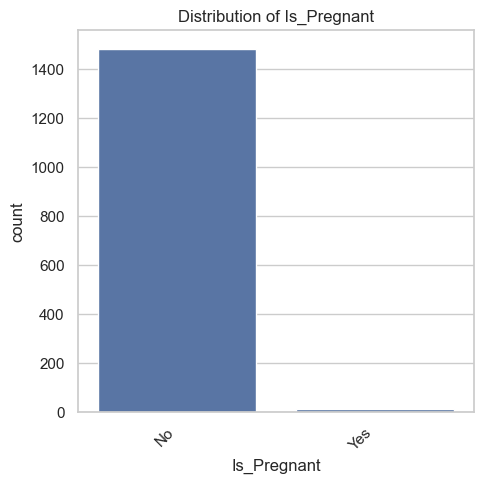

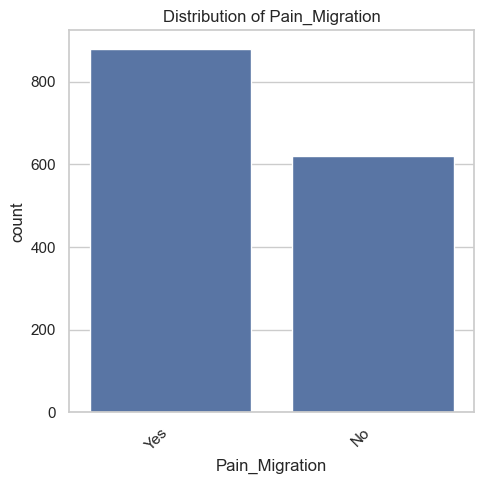

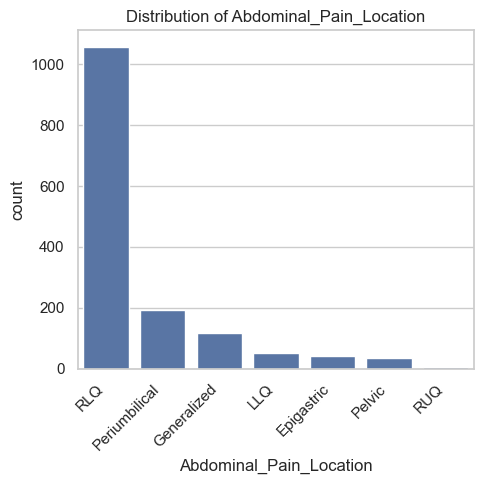

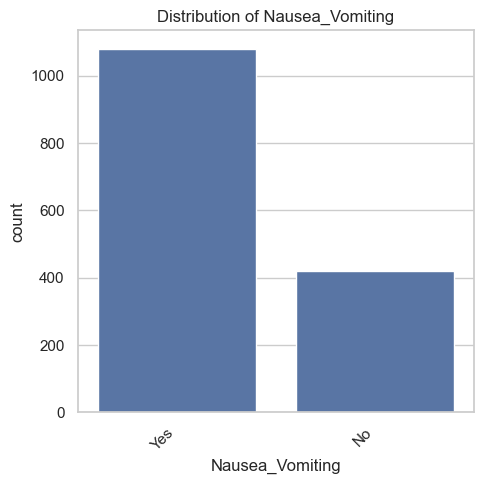

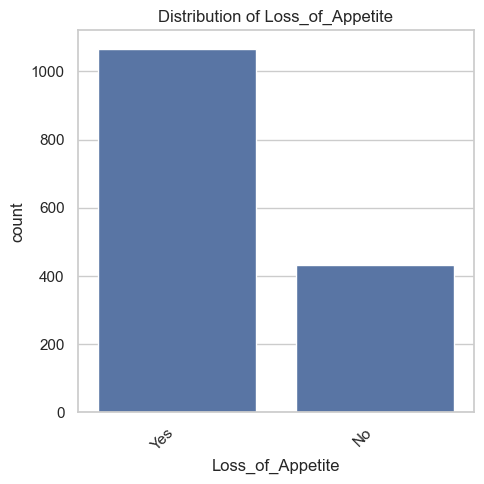

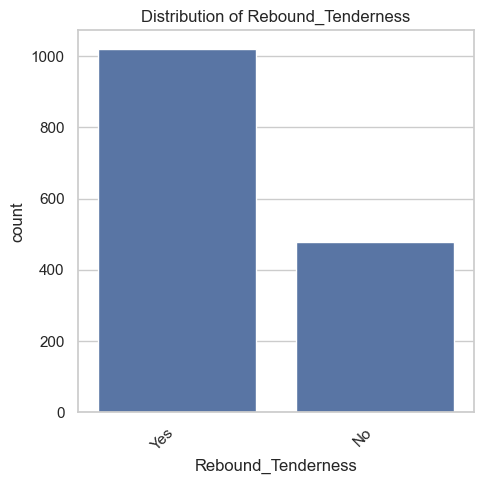

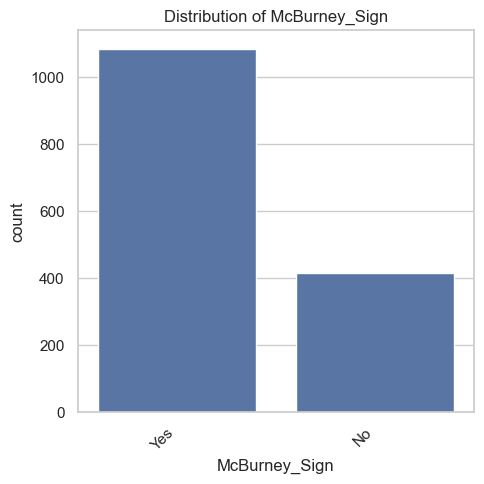

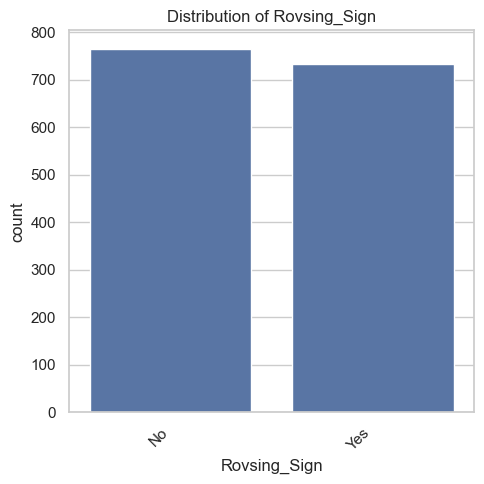

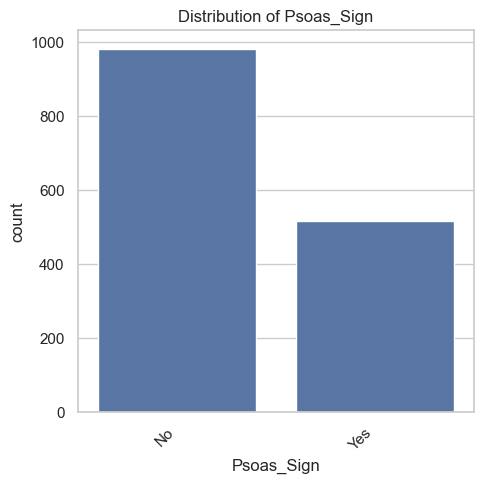

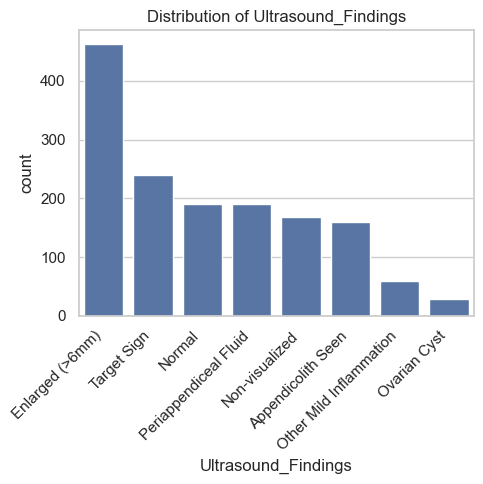

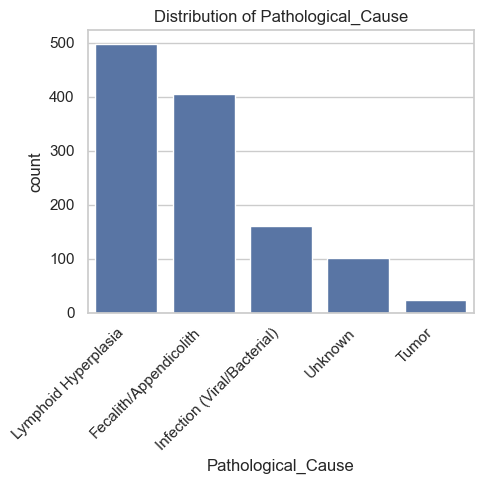

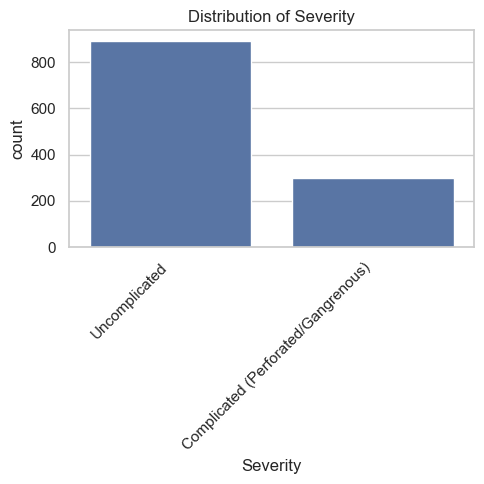

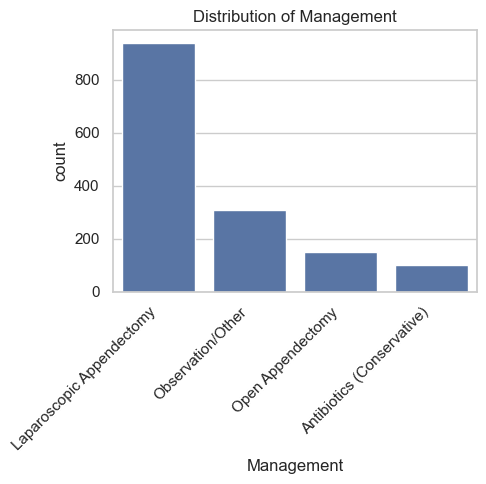

In [69]:
drop_cols = ["Patient_ID", "Final_Diagnosis"]

clean_df = df.drop(columns=drop_cols)
categorical_cols = clean_df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(5, 5))
    order = clean_df[col].value_counts().index
    sns.countplot(data=clean_df, x=col, order=order)
    plt.title("Distribution of " + col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

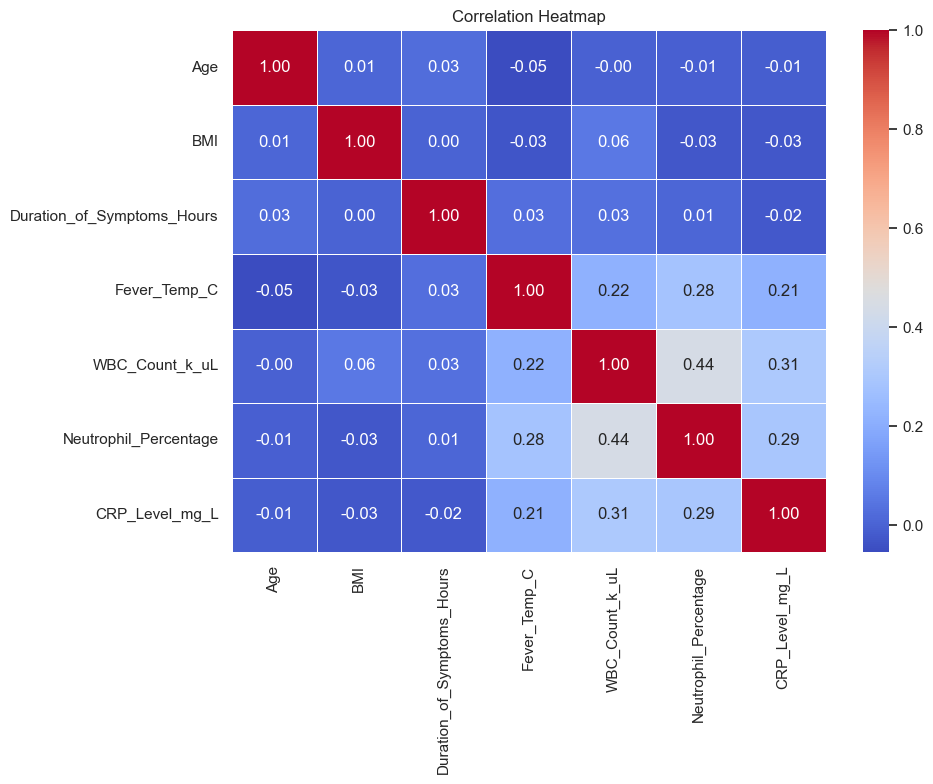

In [70]:
corr = clean_df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10 , 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Almost no relation at all

Numeric vs target

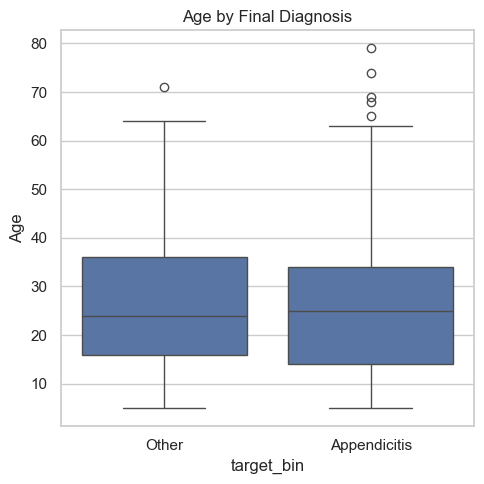

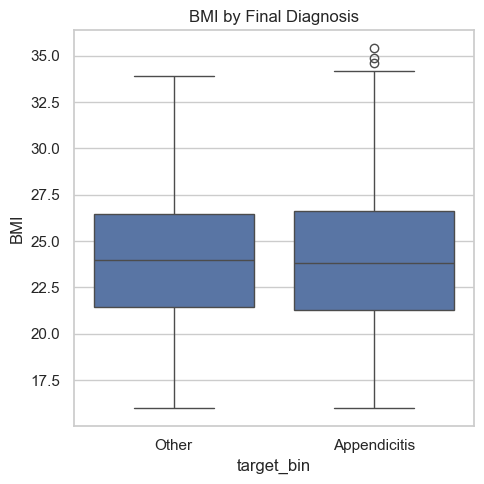

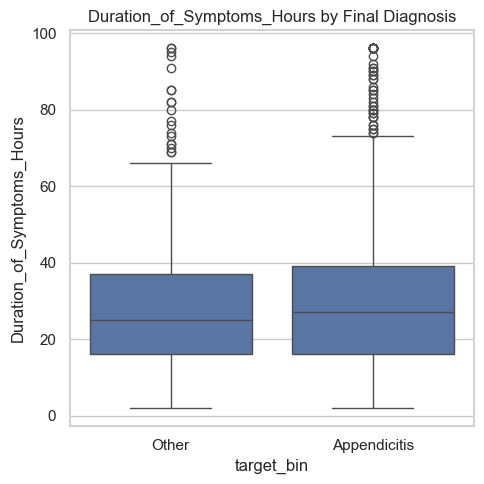

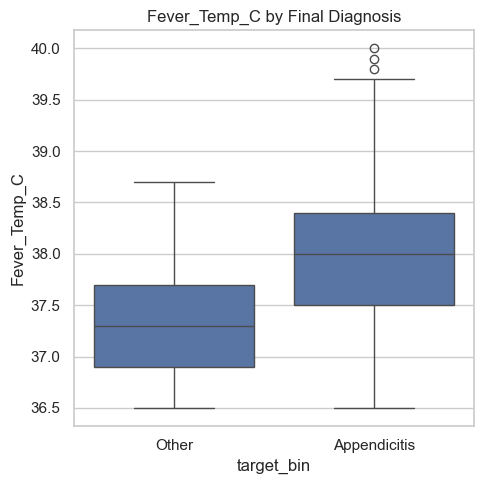

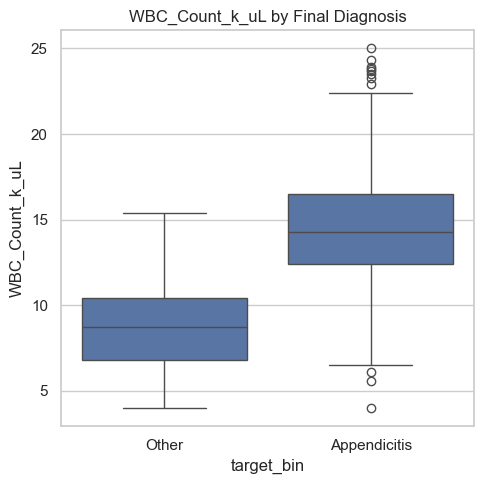

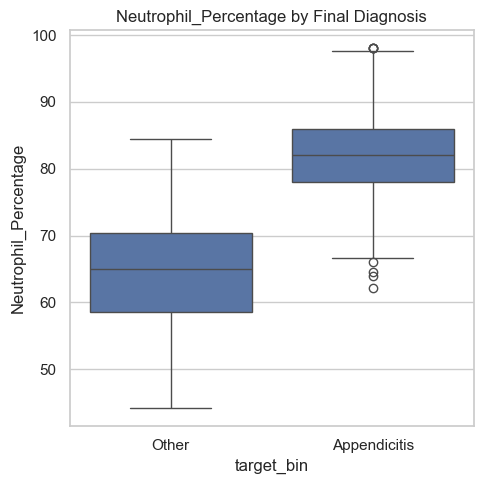

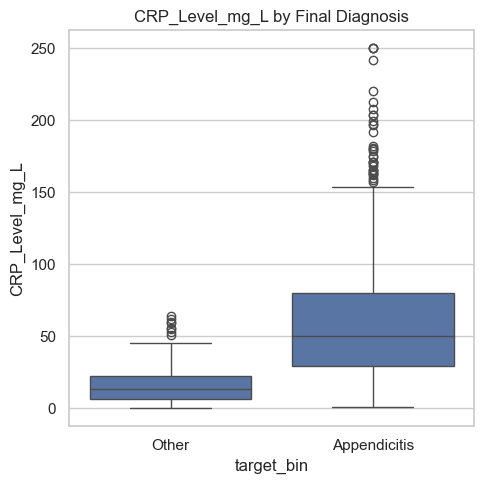

In [71]:
df['target_bin'] = (df['Final_Diagnosis'] == 'Appendicitis').astype(int)

for col in numeric_cols:
    plt.figure(figsize=(5, 5))
    sns.boxplot( x='target_bin', y=col, data=df)
    plt.title(f'{col} by Final Diagnosis')
    plt.xticks([0, 1], ['Other', 'Appendicitis'])
    plt.tight_layout()
    plt.show()
    
# plt.figure(figsize=(20,16))
# for i, col in enumerate(numeric_cols, 1):
#     plt.subplot(3, 3, i)
#     sns.boxplot(x='target_bin', y=col, data=df)
#     plt.title(f'{col} by Final Diagnosis')
#     plt.xticks([0, 1], ['Other', 'Appendicitis'])

In [72]:
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['Final_Diagnosis'], normalize='index') * 100
    display(ct.round(2))
    
    # ct.plot(kind='bar', stacked=True, figsize=(5, 5))
    # plt.title(f"{col} vs Final Diagnosis")
    # plt.ylabel("Precentage %")
    # plt.xticks(rotation=45, ha="right")
    # plt.tight_layout()
    # plt.show()    

Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Gender,,,,,,,,
Female,79.85,2.63,4.38,0.00,2.34,3.5,3.8,3.50
Male,78.90,0.00,5.64,4.66,6.26,0.0,0.0,4.54


Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Is_Pregnant,,,,,,,,
No,79.39,1.14,5.05,2.56,4.51,1.48,1.75,4.11
Yes,73.33,6.67,6.67,0.00,0.00,13.33,0.00,0.00


Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Pain_Migration,,,,,,,,
No,58.39,2.74,10.16,5.32,9.03,3.23,3.23,7.90
Yes,94.09,0.11,1.48,0.57,1.25,0.45,0.68,1.36


Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Abdominal_Pain_Location,,,,,,,,
Epigastric,0.00,0.00,23.81,19.05,26.19,4.76,0.00,26.19
Generalized,52.59,3.45,12.07,6.90,13.79,2.59,0.86,7.76
LLQ,0.00,5.88,27.45,11.76,19.61,0.00,17.65,17.65
Pelvic,0.00,14.29,17.14,0.00,14.29,20.00,11.43,22.86
Periumbilical,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
RLQ,88.00,0.57,3.02,1.51,2.36,1.13,1.13,2.27
RUQ,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Nausea_Vomiting,,,,,,,,
No,62.05,1.43,8.83,5.49,8.35,3.82,2.63,7.40
Yes,86.03,1.11,3.61,1.39,2.96,0.74,1.39,2.78


...

Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Psoas_Sign,,,,,,,,
No,71.01,1.53,7.22,3.46,6.21,2.34,2.44,5.80
Yes,95.16,0.58,0.97,0.77,1.16,0.19,0.39,0.77


Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Ultrasound_Findings,,,,,,,,
Appendicolith Seen,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Enlarged (>6mm),100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Non-visualized,81.07,1.78,4.14,1.18,2.96,1.78,1.78,5.33
Normal,0.00,4.71,25.65,14.66,20.42,6.81,10.99,16.75
Other Mild Inflammation,0.00,5.08,23.73,10.17,30.51,8.47,1.69,20.34
Ovarian Cyst,0.00,10.71,21.43,7.14,17.86,10.71,3.57,28.57
Periappendiceal Fluid,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Target Sign,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Final_Diagnosis,Appendicitis
Pathological_Cause,
Fecalith/Appendicolith,100.0
Infection (Viral/Bacterial),100.0
Lymphoid Hyperplasia,100.0
Tumor,100.0
Unknown,100.0


Final_Diagnosis,Appendicitis
Severity,
Complicated (Perforated/Gangrenous),100.0
Uncomplicated,100.0


Final_Diagnosis,Appendicitis,Other (Ectopic Pregnancy (if pregnant)),Other (Gastroenteritis),Other (Kidney Stones),Other (Mesenteric Adenitis),Other (Ovarian Cyst Rupture),Other (PID),Other (UTI)
Management,,,,,,,,
Antibiotics (Conservative),100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Laparoscopic Appendectomy,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Observation/Other,0.0,5.81,24.52,12.26,21.61,7.74,8.39,19.68
Open Appendectomy,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [73]:
leakage_candidates = [
    "Patient_ID",
    "Management",
    "Pathological_Cause",
    "Severity"
]

print("Potential leakage or non-predictive columns:")
for c in leakage_candidates:
    print("-", c)

Potential leakage or non-predictive columns:
- Patient_ID
- Management
- Pathological_Cause
- Severity


In [74]:
import os

fig_dir = "../reports/figures"
os.makedirs(fig_dir, exist_ok=True)

print("Figure folder ready:", fig_dir)

Figure folder ready: ../reports/figures
